# Introduction to Convolutional Neural Networks

## Goal

The purpose of this notebook is to demonstrate the basic concepts of Convolutional Neural Networks (CNNs), including convolution, feature maps and pooling operations.

The examples are based on the Hugging Face Computer Vision Course.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

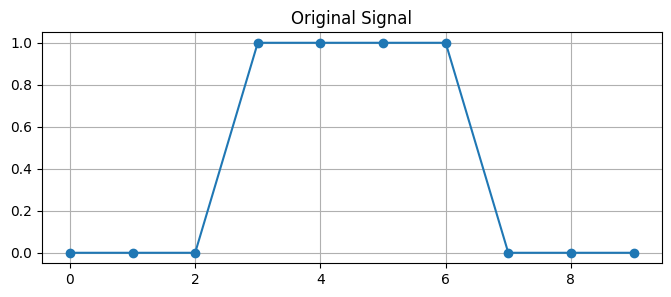

In [2]:
# Simple 1D signal

signal = np.array([0, 0, 0, 1, 1, 1, 1, 0, 0, 0])

plt.figure(figsize=(8, 3))
plt.plot(signal, marker="o")
plt.title("Original Signal")
plt.grid(True)
plt.show()

## Convolution with Kernel [-1, 1]

The kernel [-1, 1] computes the difference between neighboring values and highlights changes in the signal.

In [3]:
# Kernel from the course

kernel = np.array([-1, 1])

# Convolution

convolved = np.convolve(signal, kernel, mode="same")

print("Original signal:")
print(signal)

print("\nConvolved signal:")
print(convolved)

Original signal:
[0 0 0 1 1 1 1 0 0 0]

Convolved signal:
[ 0  0  0 -1  0  0  0  1  0  0]


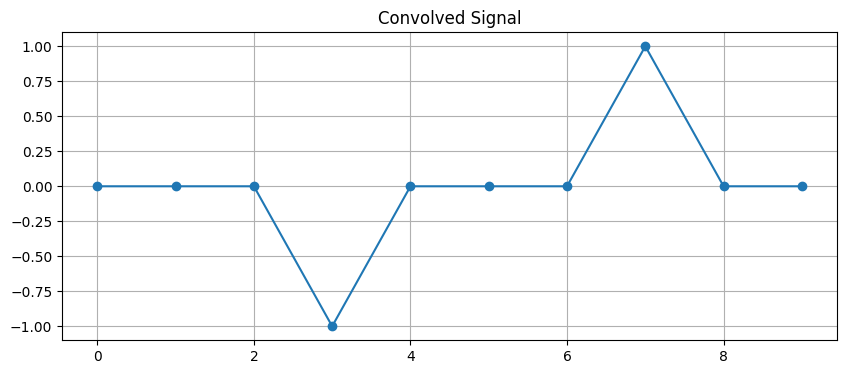

In [4]:
plt.figure(figsize=(10, 4))

plt.plot(convolved, marker="o")
plt.title("Convolved Signal")
plt.grid(True)

plt.show()

## Interpretation

The convolution operation highlights changes in the signal.

Values close to zero correspond to regions with no change.

Positive and negative peaks correspond to transitions between different regions of the signal.

This demonstrates how convolution can be used for feature extraction and edge detection.

## Edge Detection with Prewitt Filter

A 2D image can also be represented as a matrix of pixel values.

In this example, we apply a Prewitt filter to detect vertical edges in a simple image.

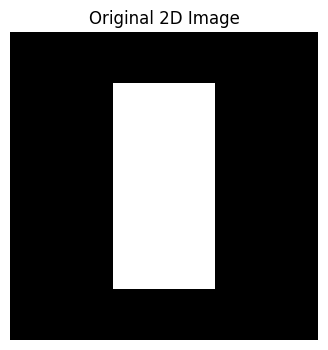

In [5]:
# Simple 2D image as a matrix

image = np.array([
    [0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 0, 0],
    [0, 0, 1, 1, 0, 0],
    [0, 0, 1, 1, 0, 0],
    [0, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0],
])

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title("Original 2D Image")
plt.axis("off")
plt.show()

In [6]:
# Prewitt filter for vertical edge detection

prewitt_kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

padded_image = np.pad(image, pad_width=1, mode="constant", constant_values=0)

feature_map = np.zeros_like(image, dtype=float)

for i in range(image.shape[0]):
    for j in range(image.shape[1]):
        region = padded_image[i:i+3, j:j+3]
        feature_map[i, j] = np.sum(region * prewitt_kernel)

print(feature_map)

[[ 0.  1.  1. -1. -1.  0.]
 [ 0.  2.  2. -2. -2.  0.]
 [ 0.  3.  3. -3. -3.  0.]
 [ 0.  3.  3. -3. -3.  0.]
 [ 0.  2.  2. -2. -2.  0.]
 [ 0.  1.  1. -1. -1.  0.]]


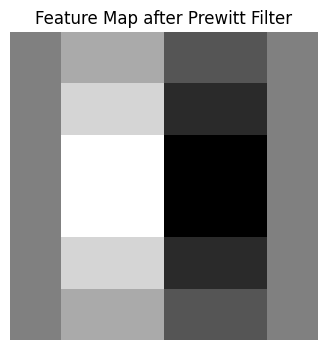

In [7]:
plt.figure(figsize=(4, 4))
plt.imshow(feature_map, cmap="gray")
plt.title("Feature Map after Prewitt Filter")
plt.axis("off")
plt.show()

## Interpretation of the Feature Map

The Prewitt filter highlights intensity changes in the image.

Bright and dark regions correspond to object boundaries.

This demonstrates how convolution can be used to detect edges and extract useful image features before classification.

## Max Pooling

Pooling reduces the size of feature maps while preserving the most important information.

In Max Pooling, the maximum value from each region is selected.

In [8]:
feature_map_example = np.array([
    [1, 30, 250, 40],
    [20, 100, 50, 20],
    [5, 10, 80, 30],
    [15, 25, 60, 10]
])

print("Original Feature Map:")
print(feature_map_example)

Original Feature Map:
[[  1  30 250  40]
 [ 20 100  50  20]
 [  5  10  80  30]
 [ 15  25  60  10]]


In [9]:
pooled = np.array([
    [
        np.max(feature_map_example[0:2, 0:2]),
        np.max(feature_map_example[0:2, 2:4])
    ],
    [
        np.max(feature_map_example[2:4, 0:2]),
        np.max(feature_map_example[2:4, 2:4])
    ]
])

print("Pooled Output:")
print(pooled)

Pooled Output:
[[100 250]
 [ 25  80]]


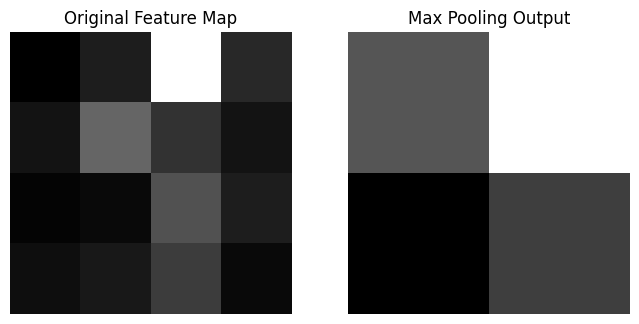

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(feature_map_example, cmap="gray")
axes[0].set_title("Original Feature Map")
axes[0].axis("off")

axes[1].imshow(pooled, cmap="gray")
axes[1].set_title("Max Pooling Output")
axes[1].axis("off")

plt.show()

## Interpretation

Max Pooling reduces the size of the feature map while preserving the strongest activations.

This helps decrease the number of parameters and improves robustness to small changes in the image.

## Simple CNN Architecture

A typical Convolutional Neural Network consists of:

1. Convolution layers for feature extraction.
2. Pooling layers for dimensionality reduction.
3. Flatten operation.
4. Dense layers for classification.

Architecture:

Image
↓
Convolution
↓
Pooling
↓
Flatten
↓
Dense
↓
Output

# Conclusion

In this notebook, we explored the fundamental concepts of Convolutional Neural Networks.

We demonstrated:

- 1D convolution;
- feature extraction;
- edge detection using the Prewitt filter;
- max pooling;
- the basic CNN architecture.

These operations form the foundation of modern deep learning methods for computer vision.